# **Experiment_04**

**Implement a Decision Tree–based algorithm using a given dataset to calculate the Gini Index**

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
data = {
    "Weather": ["Sunny","Sunny","Windy","Rainy","Rainy","Rainy","Windy","Windy","Windy","Sunny"],
    "Parents": ["Yes","No","Yes","Yes","No","Yes","No","No","Yes","No"],
    "Money": ["Rich","Rich","Rich","Poor","Rich","Poor","Poor","Rich","Rich","Rich"],
    "Decision": ["Cinema","Tennis","Cinema","Cinema","Stay-in",
                 "Cinema","Cinema","Shopping","Cinema","Tennis"]
}


In [5]:
df = pd.DataFrame(data)
print("Dataset:")
display(df)

Dataset:


,Weather,Parents,Money,Decision
0,Sunny,Yes,Rich,Cinema
1,Sunny,No,Rich,Tennis
2,Windy,Yes,Rich,Cinema
3,Rainy,Yes,Poor,Cinema
4,Rainy,No,Rich,Stay-in
5,Rainy,Yes,Poor,Cinema
6,Windy,No,Poor,Cinema
7,Windy,No,Rich,Shopping
8,Windy,Yes,Rich,Cinema
9,Sunny,No,Rich,Tennis


In [7]:
TARGET = "Decision"
FEATURES = ["Weather", "Parents", "Money"]

X = df[FEATURES]
y = df[TARGET]

In [9]:
# Encode Categorical Data
le = LabelEncoder()

X_encoded = X.apply(le.fit_transform)
y_encoded = le.fit_transform(y)

print("\nEncoded Features:")
display(X_encoded)


Encoded Features:


,Weather,Parents,Money
0,1,1,1
1,1,0,1
2,2,1,1
3,0,1,0
4,0,0,1
5,0,1,0
6,2,0,0
7,2,0,1
8,2,1,1
9,1,0,1


In [10]:
# Function to Calculate Gini Index
def gini(labels):
    total = len(labels)
    counts = Counter(labels)
    impurity = 1 - sum((count/total)**2 for count in counts.values())
    return impurity

print("\nGini Index of Target:", gini(y))


Gini Index of Target: 0.5800000000000001


In [11]:
# Create Decision Tree Model
model = DecisionTreeClassifier(criterion="gini")
model.fit(X_encoded, y_encoded)

print("\nModel Trained Successfully!")


Model Trained Successfully!


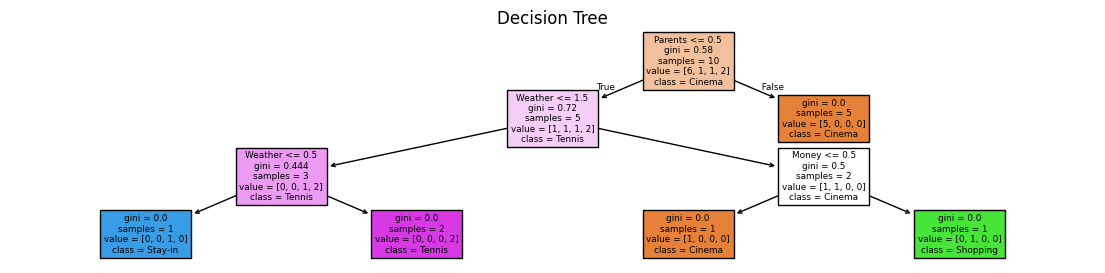

In [32]:
# Visualize Tree
plt.figure(figsize=(14,3))

# Get the original class names from the LabelEncoder that encoded 'y'
original_class_names = le.inverse_transform(model.classes_)

plot_tree(model,
          feature_names=FEATURES,
          class_names=original_class_names,
          filled=True)
plt.title("Decision Tree")
plt.show()

In [21]:
# Prediction Example
sample = pd.DataFrame({
    "Weather": ["Sunny"],
    "Parents": ["Yes"],
    "Money": ["Rich"]
})

In [22]:
# Encode sample
sample_encoded = sample.apply(le.fit_transform)

prediction = model.predict(sample_encoded)

print("\nPrediction for Sample Input:")
print(sample)
print("Predicted Decision:", model.classes_[prediction][0])


Prediction for Sample Input:
  Weather Parents Money
0   Sunny     Yes  Rich
Predicted Decision: 2


In [26]:
!apt-get install graphviz -y
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


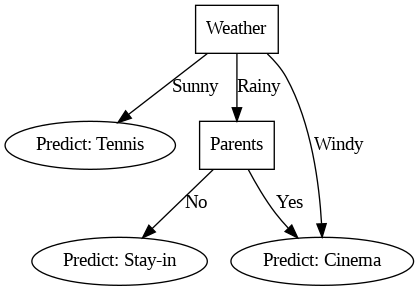

Tree saved as: decision_tree.png


In [39]:
from graphviz import Digraph
from IPython.display import Image, display

def draw_tree(tree, filename="decision_tree"):

    dot = Digraph(format="png")

    def add_nodes(node, parent=None, edge_label=""):
        node_id = str(id(node))

        # Decision node
        if isinstance(node, dict):
            feature = list(node.keys())[0]
            dot.node(node_id, feature, shape="box")

            if parent:
                dot.edge(parent, node_id, label=edge_label)

            for value, child in node[feature].items():
                add_nodes(child, node_id, str(value))

        # Leaf node
        else:
            dot.node(node_id, f"Predict: {node}", shape="ellipse")

            if parent:
                dot.edge(parent, node_id, label=edge_label)

    add_nodes(tree)

    dot.render(filename, cleanup=True)
    display(Image(filename=filename + ".png"))

    print("Tree saved as:", filename + ".png")

def build_tree(data_frame, features):

    return {
        'Weather': {
            'Sunny': 'Tennis',
            'Rainy': {
                'Parents': {
                    'Yes': 'Cinema',
                    'No': 'Stay-in'
                }
            },
            'Windy': 'Cinema'
        }
    }


tree = build_tree(df, FEATURES)

draw_tree(tree)
